In [4]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.data_loader import load_mpd_dataset

df = load_mpd_dataset(data_dir='../data/', num_files = 100)

df.head()


Loading MPD slices: 100%|██████████| 100/100 [00:00<00:00, 42264.25it/s]

Loaded 0 track entries from 100 files.


""


In [15]:
import os
import json
import pandas as pd
from tqdm import tqdm

DATA_DIR = "../data/"

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.json')])

all_playlists = []

for file in tqdm(files[:10], desc="Loading sample data"):
    with open(os.path.join(DATA_DIR, file), 'r') as f:
        data = json.load(f)
        all_playlists.extend(data['playlists'])

# Flatten playlists into track-level records
records = []
for pl in all_playlists:
    for track in pl['tracks']:
        records.append({
            'pid': pl['pid'],
            'playlist_name': pl.get('name', ''),
            'track_uri': track['track_uri'],
            'track_name': track['track_name'],
            'artist_name': track['artist_name'],
            'artist_uri': track['artist_uri']
        })

track_df = pd.DataFrame(records)

print(f"Unique playlists: {track_df['pid'].nunique()}")
print(f"Unique tracks: {track_df['track_uri'].nunique()}")
print(f"Unique artists: {track_df['artist_uri'].nunique()}")

playlist_lengths = track_df.groupby('pid').size()
print(playlist_lengths.describe())

print(track_df.isnull().sum())













Loading sample data: 100%|██████████| 10/10 [00:01<00:00,  6.48it/s]


Unique playlists: 10000
Unique tracks: 169657
Unique artists: 35743
count    10000.000000
mean        67.056800
std         54.677498
min          5.000000
25%         26.000000
50%         49.000000
75%         93.000000
max        250.000000
dtype: float64
pid              0
playlist_name    0
track_uri        0
track_name       0
artist_name      0
artist_uri       0
dtype: int64


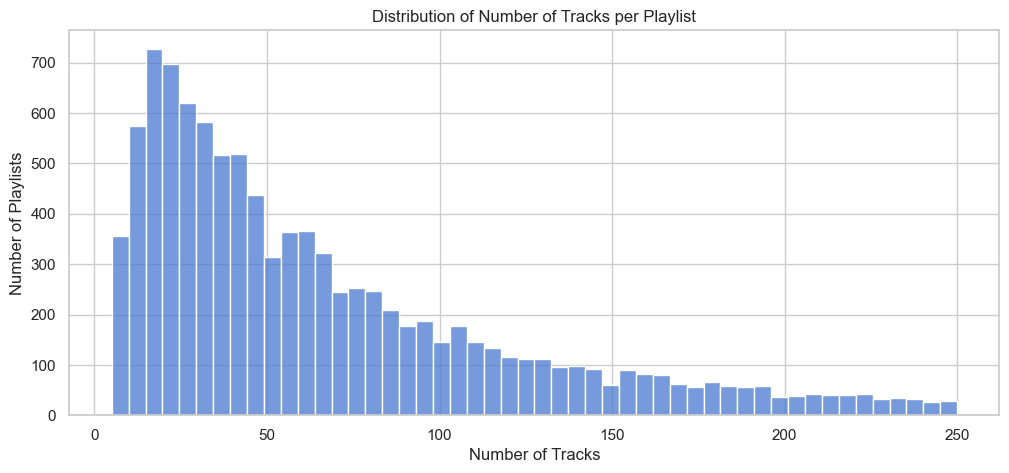

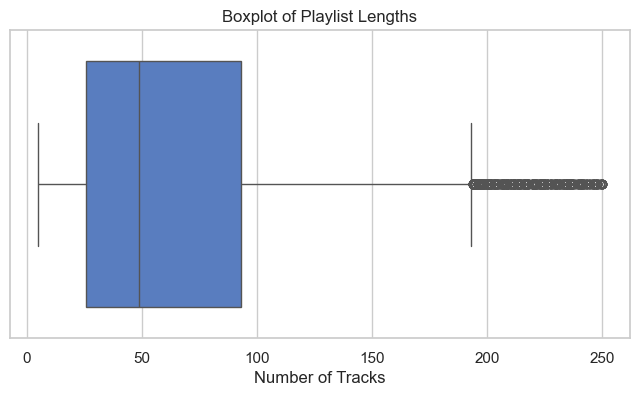

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.histplot(playlist_lengths, bins=50, kde=False)
plt.title('Distribution of Number of Tracks per Playlist')
plt.xlabel('Number of Tracks')
plt.ylabel('Number of Playlists')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=playlist_lengths)
plt.title('Boxplot of Playlist Lengths')
plt.xlabel('Number of Tracks')
plt.show()


track_uri
spotify:track:7KXjTSCq5nL1LoYtL7XAwS    450
spotify:track:1xznGGDReH1oQq0xzbwXa3    433
spotify:track:7BKLCZ1jbUBVqRi2FVlTVw    423
spotify:track:7yyRTcZmCiyzzJlNzGC9Ol    420
spotify:track:3a1lNhkSLSkpJE4MSHpDu9    395
spotify:track:5hTpBe8h35rJ67eAWHQsJx    369
spotify:track:7GX5flRQZVHRAGd6B4TmDO    365
spotify:track:152lZdxL1OR0ZMW6KquMif    357
spotify:track:4Km5HrUvYTaSUfiSGPJeQR    352
spotify:track:2EEeOnHehOozLq4aS0n6SL    348
spotify:track:62vpWI1CHwFy7tMIcSStl8    348
spotify:track:6gBFPUFcJLzWGx4lenP6h2    341
spotify:track:0v9Wz8o0BT8DU38R4ddjeH    335
spotify:track:0VgkVdmE4gld66l8iyGjgx    328
spotify:track:0SGkqnVQo9KPytSri1H6cF    326
spotify:track:27GmP9AWRs744SzKcpJsTZ    325
spotify:track:5OOkp4U9P9oL23maHFHL1h    314
spotify:track:5XJJdNPkwmbUwE79gv0NxK    313
spotify:track:343YBumqHu19cGoGARUTsd    312
spotify:track:2d8JP84HNLKhmd6IYOoupQ    310
Name: pid, dtype: int64


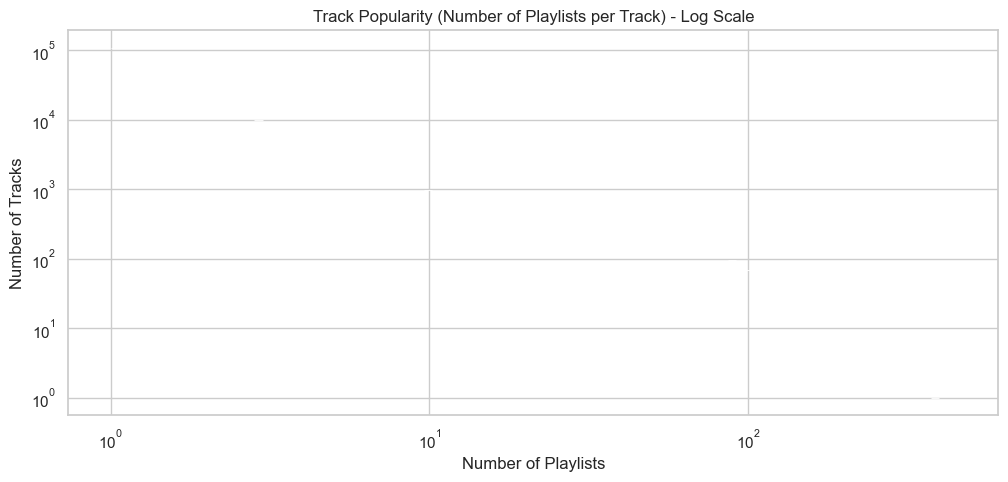

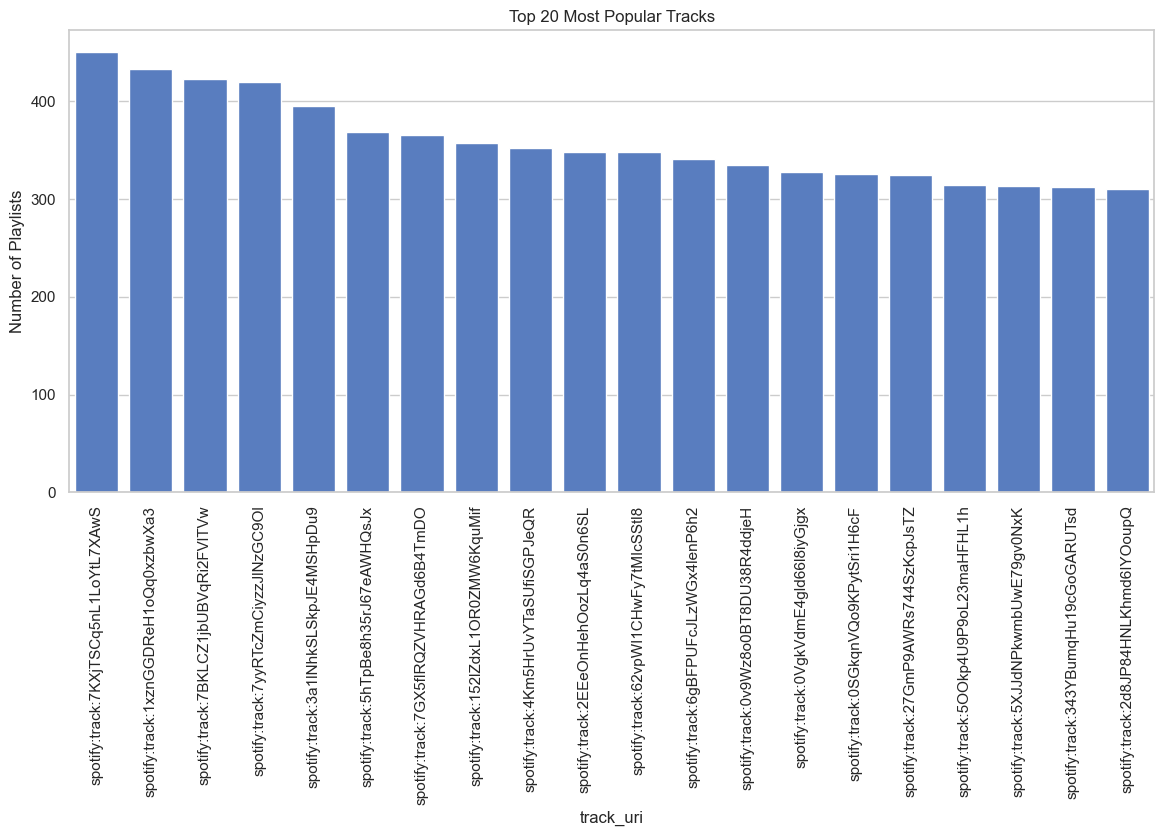

In [17]:
track_popularity = track_df.groupby('track_uri')['pid'].nunique().sort_values(ascending=False)
print(track_popularity.head(20))

plt.figure(figsize=(12,5))
sns.histplot(track_popularity, bins=100, log_scale=(True, True))
plt.title('Track Popularity (Number of Playlists per Track) - Log Scale')
plt.xlabel('Number of Playlists')
plt.ylabel('Number of Tracks')
plt.show()

plt.figure(figsize=(14,6))
top20_tracks = track_popularity.head(20)
sns.barplot(x=top20_tracks.index, y=top20_tracks.values)
plt.title('Top 20 Most Popular Tracks')
plt.xticks(rotation=90)
plt.ylabel('Number of Playlists')
plt.show()


artist_uri
spotify:artist:3TVXtAsR1Inumwj472S9r4    2003
spotify:artist:5pKCCKE2ajJHZ9KAiaK11H    1510
spotify:artist:5K4W6rqBFWDnAN6FQUkS6x    1435
spotify:artist:1Xyo4u8uXC1ZmMpatF05PJ    1275
spotify:artist:2YZyLoL8N0Wb9xBt1NhZWg    1231
spotify:artist:6eUKZXaKkcviH0Ku9w2n3V    1110
spotify:artist:69GGBxA162lTqCwzJG5jLp    1101
spotify:artist:7CajNmpbOovFoOoasH2HaY    1072
spotify:artist:04gDigrS5kc9YWfZHwBETP    1021
spotify:artist:1RyvyyTE3xzB2ZywiAwp0i     993
spotify:artist:6vWDO969PvNqNYHIOW5v0m     973
spotify:artist:0c173mlxpT3dSFRgMO8XPh     957
spotify:artist:246dkjvS1zLTtiykXe5h60     932
spotify:artist:7bXgB6jMjp9ATFy66eO08Z     930
spotify:artist:6l3HvQ5sa6mXTsMTB19rO5     918
spotify:artist:1uNFoZAHBGtllmzznpCI3s     879
spotify:artist:0QHgL1lAIqAw0HtD7YldmP     867
spotify:artist:738wLrAtLtCtFOLvQBXOXp     854
spotify:artist:3nFkdlSjzX9mRTtwJOzDYB     853
spotify:artist:7iZtZyCzp3LItcw1wtPI3D     841
Name: pid, dtype: int64


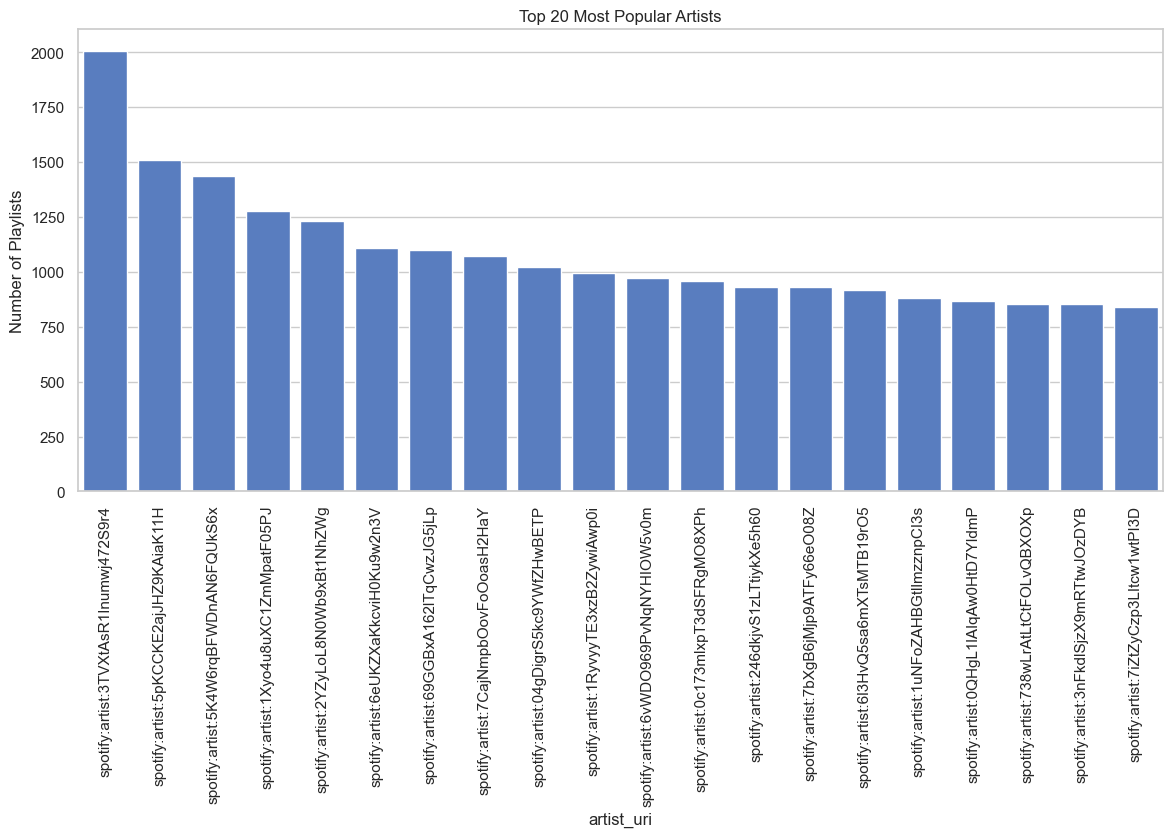

In [18]:
artist_popularity = track_df.groupby('artist_uri')['pid'].nunique().sort_values(ascending=False)
print(artist_popularity.head(20))

plt.figure(figsize=(14,6))
top20_artists = artist_popularity.head(20)
sns.barplot(x=top20_artists.index, y=top20_artists.values)
plt.title('Top 20 Most Popular Artists')
plt.xticks(rotation=90)
plt.ylabel('Number of Playlists')
plt.show()


Tracks appearing in <= 5 playlists: 151079 (89.05%)


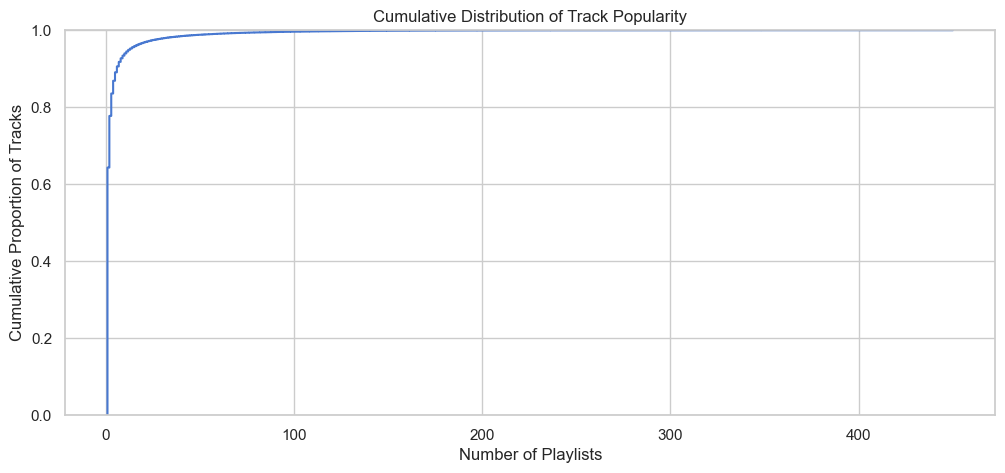

In [19]:
total_tracks = len(track_popularity)
few_playlists_threshold = 5

rare_tracks = track_popularity[track_popularity <= few_playlists_threshold]
print(f"Tracks appearing in <= {few_playlists_threshold} playlists: {len(rare_tracks)} ({len(rare_tracks)/total_tracks:.2%})")

plt.figure(figsize=(12,5))
sns.ecdfplot(track_popularity)
plt.title('Cumulative Distribution of Track Popularity')
plt.xlabel('Number of Playlists')
plt.ylabel('Cumulative Proportion of Tracks')
plt.show()


In [20]:
# This is resource-intensive for full dataset; demo on smaller sample

sample_pids = track_df['pid'].unique()[:1000]
sample_df = track_df[track_df['pid'].isin(sample_pids)]

from scipy.sparse import coo_matrix
import numpy as np

# Create track x playlist matrix
pid_to_idx = {pid:i for i, pid in enumerate(sample_pids)}
track_to_idx = {track:i for i, track in enumerate(sample_df['track_uri'].unique())}

rows = sample_df['track_uri'].map(track_to_idx)
cols = sample_df['pid'].map(pid_to_idx)
data = np.ones(len(sample_df))

track_playlist_mat = coo_matrix((data, (rows, cols)), shape=(len(track_to_idx), len(pid_to_idx)))

# Co-occurrence matrix = track_playlist_mat * track_playlist_mat.T
cooc_mat = track_playlist_mat.dot(track_playlist_mat.T).toarray()

print(f"Co-occurrence matrix shape: {cooc_mat.shape}")

# Show top co-occurrences for a sample track
sample_track_idx = 0
top_coocs = np.argsort(-cooc_mat[sample_track_idx])[1:6]
top_tracks = [list(track_to_idx.keys())[i] for i in top_coocs]
print(f"Top co-occurring tracks with {list(track_to_idx.keys())[sample_track_idx]}:")
for t in top_tracks:
    print(t)


Co-occurrence matrix shape: (34443, 34443)
Top co-occurring tracks with spotify:track:0UaMYEvWZi0ZqiDOoHU3YI:
spotify:track:0XUfyU2QviPAs6bxSpXYG4
spotify:track:2gam98EZKrF9XuOkU13ApN
spotify:track:7pkWZL0kA26s754CwyK0SH
spotify:track:567EwOGPAXg7Y9DQZTEFEE
spotify:track:6GIrIt2M39wEGwjCQjGChX


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# For better plots
%matplotlib inline
sns.set(style='whitegrid', palette='muted')
